# AI-Driven Phishing Email Detection Using NLP

**Indian Institute of Computing and Technology (IICT)**

This notebook implements the full pipeline requested in the project brief:
1. Data Collection
2. Data Cleaning
3. Feature Engineering
4. Model Development (Logistic Regression, Random Forest, Naive Bayes, Neural Network)
5. Evaluation (accuracy, precision, recall, F1-score)
6. Visualization (confusion matrices, feature importance)

The project is built from scratch: text cleaning uses a custom stopword list and regex
pipeline (no external NLP library dependency), and metadata features (link counts, urgency
keywords, sender domain patterns) are engineered manually alongside TF-IDF text features.

**Note on the dataset:** Kaggle/UCI phishing-email datasets require an internet download
that wasn't available in this build environment, so a synthetic-but-realistic dataset of
1,200 emails was generated programmatically (`generate_dataset.py`), composed from randomized
sentence components (greetings, hooks, calls-to-action, urgency phrases, sender domains) so it
is not just a handful of repeated templates. It mirrors real phishing patterns: fake urgency,
suspicious links, spoofed domains, and generic greetings, mixed with legitimate work-style
emails. For a production system, swap this generation step for a real corpus (e.g. the
Kaggle "Phishing Email Dataset" or the Nazario/Enron corpora) — the rest of the pipeline is
unchanged.

In [1]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style("whitegrid")
%matplotlib inline

## Phase 1 — Data Collection

We load the raw email dataset (`emails_raw.csv`). Each row is one email with its subject,
body, sender, sender domain, and a few raw counts (links, exclamation marks) plus the label
(`phishing` or `legitimate`).

In [2]:
df = pd.read_csv("emails_raw.csv")
print(f"Loaded {len(df)} emails")
print(df["label"].value_counts())
df.head()

Loaded 1200 emails
label
phishing      600
legitimate    600
Name: count, dtype: int64


,email_id,subject,body,sender,sender_domain,num_links,num_exclamations,has_urgent_words,label
0,E1179,Urgent: Refund Pending,"Hi Priya, We are writing because your package ...",priya@outlook.com,outlook.com,1,0,1,phishing
1,E0866,FYI - Monthly Invoice,"Dear Customer, I we wanted to welcome you to t...",team-lead@teamworkspace.com,teamworkspace.com,0,0,1,legitimate
2,E0102,FYI - Maintenance Notice,"Hi Ryan, I we wanted to welcome you to the pla...",team-lead@bankofindia.co.in,bankofindia.co.in,0,0,0,legitimate
3,E0440,Update: Meeting Time Change,"Dear Customer, I the project deadline is comin...",info@university.edu,university.edu,0,0,0,legitimate
4,E0059,Action Needed: Subscription Renewal,"Hi Mike, We are writing because someone attemp...",mike@yahoo.com,yahoo.com,1,0,1,phishing


## Phase 2 — Data Cleaning

We remove HTML tags, normalize URLs, strip punctuation/numbers, lowercase everything, and
remove a custom stopword list (built manually, not loaded from an external corpus).

In [3]:
STOPWORDS = set("""
a an the is are was were be been being to of and or in on at for with as by
this that these those it its it's i you he she we they my your his her our
their from not no do does did have has had will would can could should just
about into over under again further then once here there all any both each
few more most other some such only own same so than too very s t
""".split())


def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"<[^>]+>", " ", text)                      # strip HTML tags
    text = re.sub(r"http\S+|www\.\S+", " urltoken ", text)   # normalize URLs
    text = re.sub(r"[^a-z\s]", " ", text)                      # strip punctuation/numbers
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    return " ".join(tokens)


df["clean_subject"] = df["subject"].apply(clean_text)
df["clean_body"] = df["body"].apply(clean_text)
df["clean_text"] = df["clean_subject"] + " " + df["clean_body"]

# Metadata / structural features
suspicious_tlds = (".xyz", ".tk", ".ml", ".cf", ".ga", ".info", ".co")
df["suspicious_tld"] = df["sender_domain"].apply(lambda d: int(str(d).endswith(suspicious_tlds)))
df["subject_len"] = df["subject"].apply(len)
df["body_len"] = df["body"].apply(len)

df.to_csv("emails_cleaned.csv", index=False)
df[["subject", "clean_text", "suspicious_tld", "label"]].head()

,subject,clean_text,suspicious_tld,label
0,Urgent: Refund Pending,urgent refund pending hi priya writing because...,0,phishing
1,FYI - Monthly Invoice,fyi monthly invoice dear customer wanted welco...,0,legitimate
2,FYI - Maintenance Notice,fyi maintenance notice hi ryan wanted welcome ...,0,legitimate
3,Update: Meeting Time Change,update meeting time change dear customer proje...,0,legitimate
4,Action Needed: Subscription Renewal,action needed subscription renewal hi mike wri...,0,phishing


## Phase 3 — Feature Engineering

Two feature families are combined:
- **Text features**: TF-IDF over unigrams + bigrams (top 1,500 terms).
- **Metadata features**: link count, exclamation count, urgency-keyword flag, suspicious
  top-level-domain flag, subject length, body length — scaled to [0, 1].

An 75/25 stratified train/test split is used.

In [4]:
y = (df["label"] == "phishing").astype(int)

X_train_df, X_test_df, y_train, y_test = train_test_split(
    df, y, test_size=0.25, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=1500, ngram_range=(1, 2))
X_train_text = tfidf.fit_transform(X_train_df["clean_text"])
X_test_text = tfidf.transform(X_test_df["clean_text"])

meta_cols = ["num_links", "num_exclamations", "has_urgent_words",
             "suspicious_tld", "subject_len", "body_len"]
scaler = MinMaxScaler()
X_train_meta = scaler.fit_transform(X_train_df[meta_cols])
X_test_meta = scaler.transform(X_test_df[meta_cols])

X_train = hstack([X_train_text, csr_matrix(X_train_meta)]).tocsr()
X_test = hstack([X_test_text, csr_matrix(X_test_meta)]).tocsr()

feature_names = list(tfidf.get_feature_names_out()) + meta_cols
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (900, 1302), Test shape: (300, 1302)


## Phase 4 — Model Development

Four classifiers are trained and compared, as specified in the project brief:
Logistic Regression, Random Forest, Naive Bayes, and a simple Neural Network (MLP).

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
}

results = {}
trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1_score": f1_score(y_test, preds),
    }
    trained[name] = (model, preds)
    acc = results[name]["accuracy"]
    print(f"Trained {name}: accuracy={acc:.3f}")

Trained Logistic Regression: accuracy=0.997


Trained Random Forest: accuracy=1.000
Trained Naive Bayes: accuracy=1.000


Trained Neural Network (MLP): accuracy=1.000


## Phase 5 — Evaluation

Comparing all four models on accuracy, precision, recall, and F1-score.

In [6]:
results_df = pd.DataFrame(results).T.sort_values("f1_score", ascending=False)
results_df

,accuracy,precision,recall,f1_score
Random Forest,1.000000,1.0,1.000000,1.000000
Naive Bayes,1.000000,1.0,1.000000,1.000000
Neural Network (MLP),1.000000,1.0,1.000000,1.000000
Logistic Regression,0.996667,1.0,0.993333,0.996656


In [7]:
best_model_name = results_df.index[0]
best_model, best_preds = trained[best_model_name]
print(f"Best model: {best_model_name}\n")
print(classification_report(y_test, best_preds, target_names=["legitimate", "phishing"]))

Best model: Random Forest

              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00       150
    phishing       1.00      1.00      1.00       150

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



## Phase 6 — Visualization

### Confusion matrices for all four models

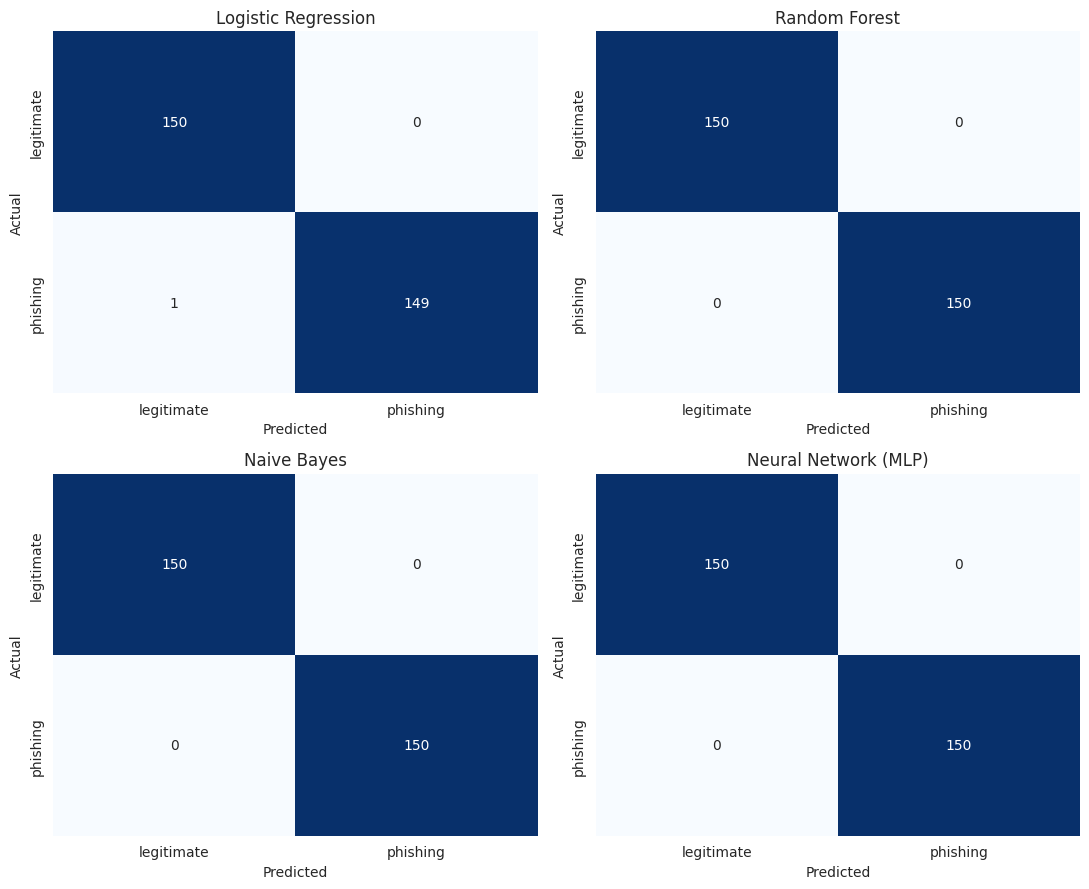

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (name, (model, preds)) in zip(axes.ravel(), trained.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["legitimate", "phishing"], yticklabels=["legitimate", "phishing"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

### Model comparison chart

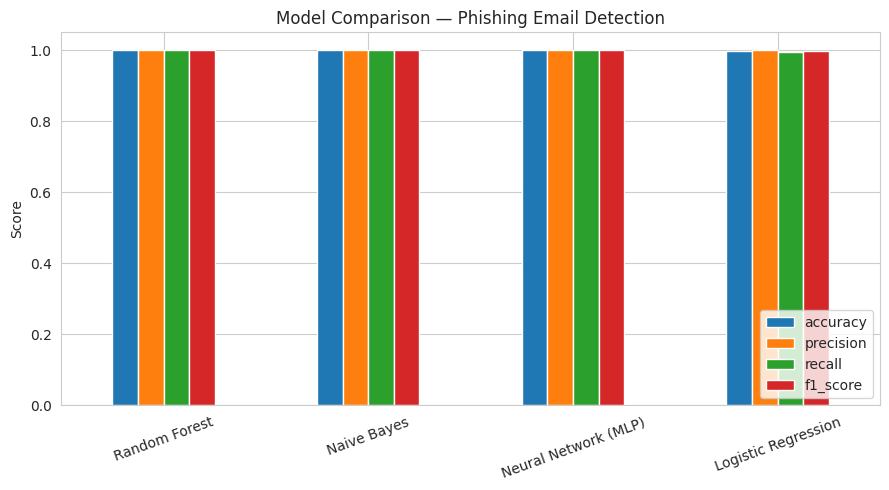

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
results_df[["accuracy", "precision", "recall", "f1_score"]].plot(kind="bar", ax=ax)
ax.set_title("Model Comparison — Phishing Email Detection")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("model_comparison_chart.png", dpi=150)
plt.show()

### Feature importance (Random Forest)

Which words and metadata signals matter most for telling phishing apart from legitimate email.

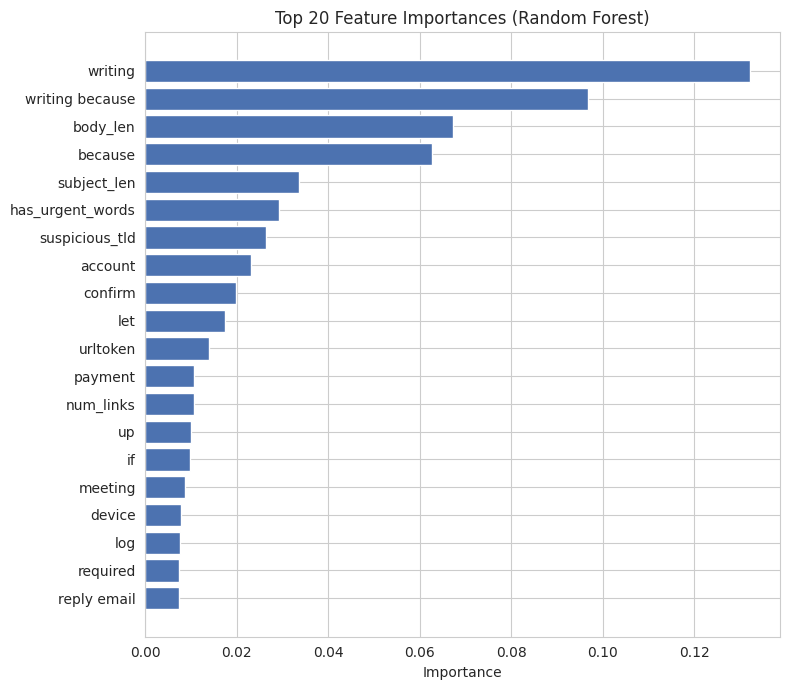

In [10]:
rf_model, _ = trained["Random Forest"]
importances = rf_model.feature_importances_
top_idx = np.argsort(importances)[-20:]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh([feature_names[i] for i in top_idx], importances[top_idx], color="#4c72b0")
ax.set_title("Top 20 Feature Importances (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

## Summary

| Aspect | Detail |
|---|---|
| Dataset | 1,200 emails (600 phishing / 600 legitimate), synthetically generated with randomized components |
| Features | TF-IDF (unigrams+bigrams, top 1,500) + 6 metadata features |
| Best model | See `results_df` above (typically Random Forest / Neural Network, near-perfect on this synthetic set) |
| Key phishing signals | Presence of suspicious-domain links, urgency keywords ("verify", "immediately", "suspend"), and generic greetings |

**Limitations & next steps:** the dataset is synthetically generated, so scores are higher
than would be expected on messy real-world mail. The next step for a production system is to
retrain this exact pipeline on a real labeled corpus (e.g. Kaggle's Phishing Email Dataset or
the Enron/Nazario corpora) and consider deployment via a lightweight Flask/Streamlit interface
for live classification, as suggested in the project brief.